# Customer Segmentation Using Clustering

## 1. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution and relationships among customer attributes such as age, annual income, and spending score.

In [36]:
import pandas as pd

In [37]:
df = pd.read_csv("../data/processed_mall_customers.csv")

In [38]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [39]:
df.shape

(200, 5)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [41]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [42]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

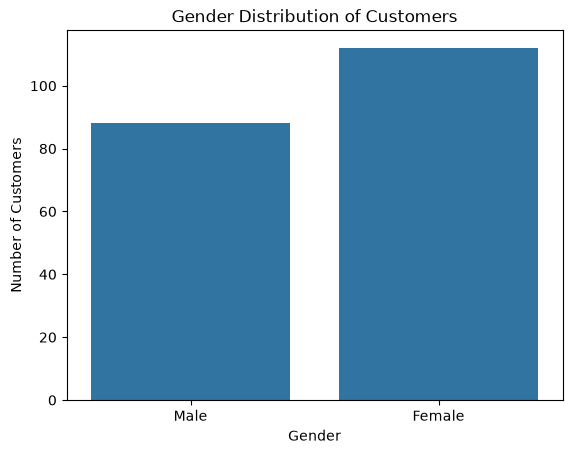

In [45]:
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

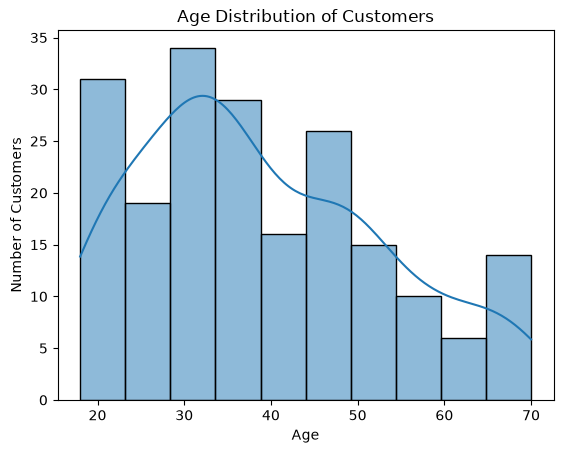

In [46]:
sns.histplot(data=df, x='Age', bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

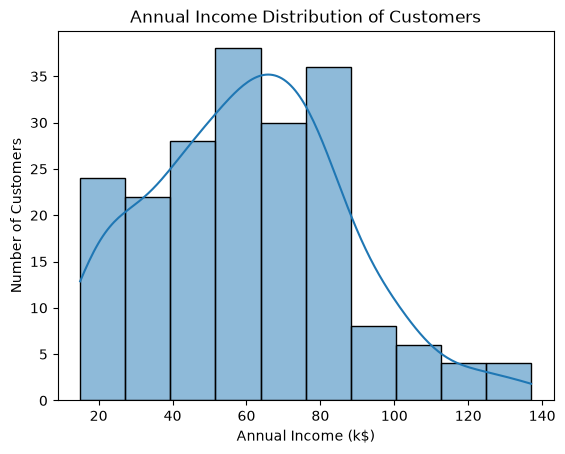

In [47]:
sns.histplot(data=df, x='Annual Income (k$)', bins=10, kde=True)
plt.title('Annual Income Distribution of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')
plt.show()

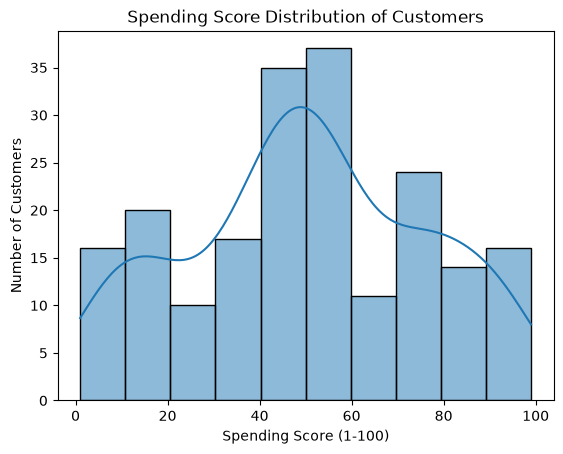

In [48]:
sns.histplot(data=df, x='Spending Score (1-100)', bins=10, kde=True)
plt.title('Spending Score Distribution of Customers')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Number of Customers')
plt.show()

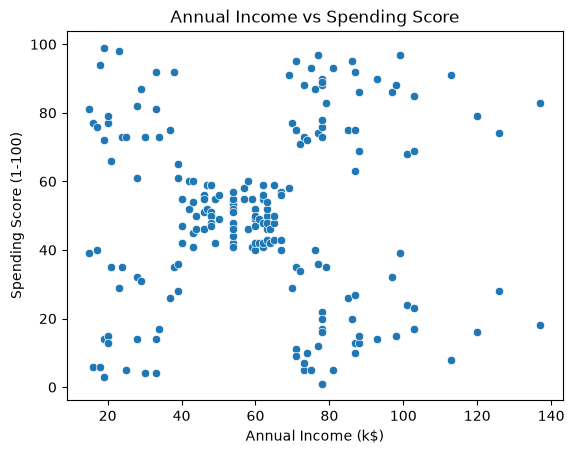

In [49]:
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

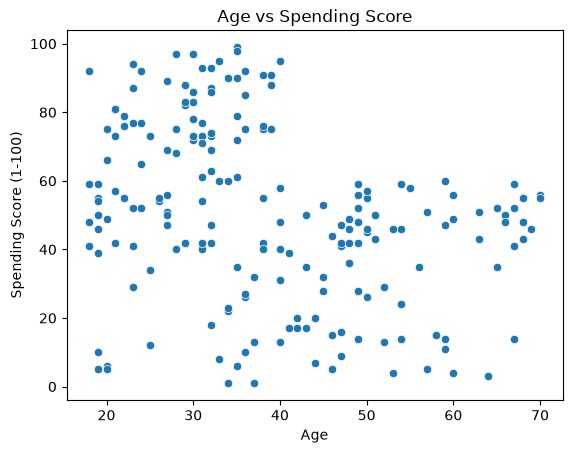

In [50]:
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)')
plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

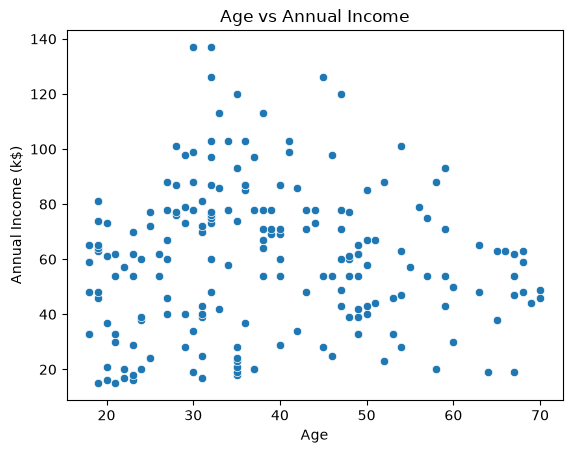

In [51]:
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)')
plt.title('Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

In [52]:
import seaborn as sns

In [53]:
import matplotlib.pyplot as plt

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
correlation = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()

correlation

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


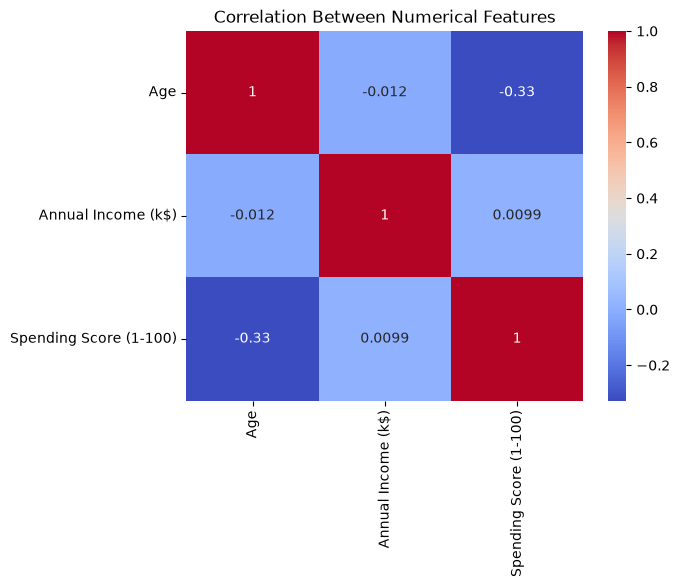

In [56]:
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')
plt.show()

## 2. Feature Selection

CustomerID was excluded because it is only an identifier and does not provide meaningful information for clustering. Annual Income and Spending Score were selected as the main numerical features for customer segmentation.

In [77]:
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 3. Feature Scaling

StandardScaler was applied to the selected features to bring them to a comparable scale. This is important for K-Means clustering because the algorithm uses distance calculations to form clusters.

In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
scaler = StandardScaler()

In [89]:
scaled_features = pd.DataFrame(
    X_scaled,
    columns=features.columns
)

scaled_features.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [90]:
X_scaled = scaler.fit_transform(features)

In [91]:
scaled_features.describe()

,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02
mean,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00
min,-1.738999e+00,-1.910021e+00
25%,-7.275093e-01,-5.997931e-01
50%,3.587926e-02,-7.764312e-03
75%,6.656748e-01,8.851316e-01
max,2.917671e+00,1.894492e+00


## 4. Final Scaled Dataset

The scaled customer features were saved as `scaled_customer_data.csv`. This dataset contains 200 customer records and the two selected features, Annual Income and Spending Score, and is ready for the K-Means clustering stage.

In [96]:
scaled_features.to_csv("../data/scaled_customer_data.csv", index=False)

In [97]:
scaled_features.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [98]:
import os

os.path.exists("../data/scaled_customer_data.csv")

True

In [99]:
pd.read_csv("../data/scaled_customer_data.csv").shape

(200, 2)